# Space-lag ADCIG (2D & 3D) — subsurface-offset extended imaging condition

Angle-domain common-image gathers (ADCIGs) decompose the migrated image at each
subsurface point by *reflection angle* — the primary MVA / AVA diagnostic of a
depth migration.  This notebook builds them the **wavefield-continuation** way
(Sava & Fomel, 2003): a two-step recipe.

**Step 1 — subsurface-offset (space-lag) CIG.**  Accumulate a horizontal
subsurface half-offset lag $h$ (a shift between the source and receiver
wavefields *at the image point*, along the fast $x$ axis):

$$E(z,x,h)=\sum_t u_s(z,\,x-h,\,t)\;u_r(z,\,x+h,\,t).$$

The $h{=}0$ slice is exactly the standard zero-lag RTM image.

**Step 2 — slant-stack to angle.**  Radon-transform the $(\lambda,z)$ panel at
each location:

$$A(z_0,x,\theta)=\sum_\lambda E\!\left(z_0-\lambda\tan\theta,\;x,\;\lambda\right),
\qquad \tan\theta = k_\lambda/k_z.$$

On the CUDA backend Step 1 is a built-in toggle — `solver.compute_adcig = True`
(off by default, like `compute_illumination`); Step 2 is a cheap Python
post-process, so you can re-pick the angle sampling without re-running the solve.

> **Requires boundary-saving mode** (`boundary_saving_config={'enabled': True}`):
> the full/checkpoint forwards store $v_p^2\nabla^2 u$ for the gradient, not the
> raw pressure the imaging condition needs.  `compute_adcig` raises a clear error
> otherwise.  Both **acoustic2d** and **acoustic3d** are supported (lag along $x$).
>
> A pure-eager alternative (no C++, works on CPU) exists via the
> `register_gradient` hook — see `16_adcig.ipynb`, which focuses on that
> custom-backward mechanism using the Poynting recipe.

## Imports + setup

In [1]:
import sys, pathlib, math, time
_repo = pathlib.Path().resolve().parents[1]           # worktree root
if str(_repo / 'src') not in sys.path:
    sys.path.insert(0, str(_repo / 'src'))

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

import sweep
from sweep.equations import Acoustic, Acoustic3D
from sweep.propagator.torch import PropTorch
from sweep.signal import ricker

print('sweep :', sweep.__file__)                       # provenance — which build?
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

sweep : /home/wangs0j/sweep-local/sweep-adcig/src/sweep/__init__.py
device: cuda


## Helpers

`run_adcig` builds a boundary-saving solver, turns on `compute_adcig`, and stacks
the space-lag cube (and the receiver illumination) over shots.  `slant_stack`
maps one `(lag, z)` panel to angle.  Both are dimension-agnostic — the same code
drives 2D (`Acoustic`) and 3D (`Acoustic3D`); the lag is along the fast `x` axis.

In [2]:
def run_adcig(eq, shape, wav, src_list, rec, vp_true, vp_smooth, L,
              abcn=20, dh=10.0, dt=1e-3, nt=1400):
    '''Multi-shot space-lag ADCIG via the CUDA compute_adcig toggle (BS mode).
    Returns E (nlag, *shape) space-lag cube and den (*shape) receiver illumination,
    both stacked over shots and cropped to model shape.'''
    solver = PropTorch(eq, backend='torch', impl='c', use_ckpt=False,
                       boundary_saving_config={'enabled': True, 'storage': 'gpu'},
                       shape=shape, abcn=abcn, dh=dh, dt=dt, dev=device, nt=nt, B=1)
    solver.compute_adcig = True
    solver.adcig_max_lag = L                 # lag in cells -> +/- L*dh half-offset
    solver.compute_illumination = True       # receiver illumination for gather normalization
    vt = torch.tensor(vp_true, device=device)
    vs = torch.tensor(vp_smooth, device=device)
    E = den = None
    t0 = time.time()
    for k, src in enumerate(src_list):
        with torch.no_grad():                # observed on the true model
            obs = solver(wav, src, rec, models=[vt])
        vp = vs.clone().requires_grad_(True)  # migrate on the smooth background
        syn = solver(wav, src, rec, models=[vp])
        (0.5 * ((syn - obs) ** 2).sum()).backward()   # adjoint source = syn - obs
        e = solver.adcig.detach(); d = solver.receiver_illumination.detach()
        E = e.clone() if E is None else E + e
        den = d.clone() if den is None else den + d
    print(f'  {len(src_list)} shots in {time.time()-t0:.1f}s   cube {tuple(E.shape)}')
    return E.cpu().numpy(), den.cpu().numpy()


def slant_stack(E_col, LAGS, angles):
    '''(nlag, nz) space-lag panel -> (n_angle, nz) angle gather.'''
    nlag, Z = E_col.shape
    zc = np.arange(Z, dtype=np.float64)
    Et = E_col * np.hanning(nlag)[:, None]           # lag taper vs truncation
    A = np.zeros((len(angles), Z))
    for ai, adeg in enumerate(angles):
        p = math.tan(math.radians(adeg)); acc = np.zeros(Z)
        for j in range(nlag):
            acc += np.interp(zc - LAGS[j] * p, zc, Et[j], left=0.0, right=0.0)
        A[ai] = acc
    return A

## 2D — five-layer model

Four flat reflectors at 200/400/600/800 m; migrate on a depth-smoothed background
so the residual is (mostly) reflected energy.  Shots run along the surface; the
$x$-space-lag gathers then carry the reflection-angle information.

  14 shots in 1.2s   cube (81, 100, 140)


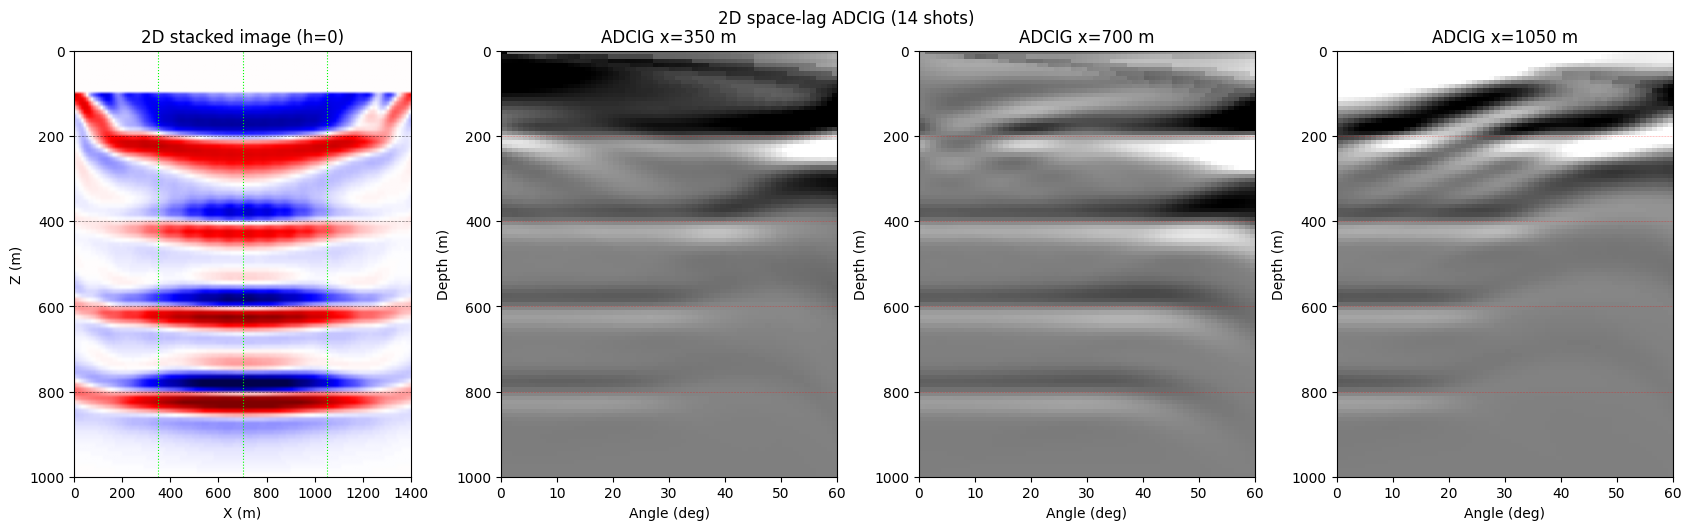

In [3]:
nz, nx = 100, 140; dh = 10.0; dt = 1e-3; nt = 1400; abcn = 20; order = 8
vp_true = np.full((nz, nx), 1500., np.float32)
vp_true[20:] = 1600.; vp_true[40:] = 1700.; vp_true[60:] = 1800.; vp_true[80:] = 1900.
vp_smooth = gaussian_filter1d(vp_true, sigma=8, axis=0).astype(np.float32)
REFL_M = [200, 400, 600, 800]

t = np.arange(nt, dtype=np.float32) * dt
wav = (1000.0 * ricker(t - 0.1, f=12.0)).astype(np.float32)
shot_x = np.arange(20, nx - 15, 8, dtype=np.int64)
src_list = [np.array([[int(sx), 1]], dtype=np.int64) for sx in shot_x]
recx = np.arange(0, nx, dtype=np.int64)
rec = np.stack([recx, np.ones_like(recx)], axis=1)[None]

L = 40; LAGS = np.arange(-L, L + 1, dtype=np.int64)           # +/- 400 m half-offset
E, den = run_adcig(Acoustic(spatial_order=order, device=device), (nz, nx),
                   wav, src_list, rec, vp_true, vp_smooth, L, abcn, dh, dt, nt)

NA = 60; angles = np.linspace(0, 60, NA)
x_loc_m = [350, 700, 1050]; x_cols = [int(round(xm / dh)) for xm in x_loc_m]
gathers = {xm: slant_stack(E[:, :, xc], LAGS, angles) for xm, xc in zip(x_loc_m, x_cols)}
img = E[L] / (den + 1e-30); img[:10] = 0                       # h=0 image, illum-normalized

fig, axes = plt.subplots(1, 1 + len(x_cols), figsize=(4.2 * (1 + len(x_cols)), 5),
                         constrained_layout=True)
vl = np.percentile(np.abs(img), 99) or 1.0
axes[0].imshow(img, cmap='seismic', vmin=-vl, vmax=vl, aspect='auto',
               extent=[0, nx * dh, nz * dh, 0])
for zm in REFL_M: axes[0].axhline(zm, color='k', lw=0.5, ls='--', alpha=0.5)
for xm in x_loc_m: axes[0].axvline(xm, color='lime', lw=0.8, ls=':')
axes[0].set_title('2D stacked image (h=0)'); axes[0].set_xlabel('X (m)'); axes[0].set_ylabel('Z (m)')
for ax, xm in zip(axes[1:], x_loc_m):
    g = gathers[xm]; vv = np.percentile(np.abs(g[:, 10:]), 98) or 1.0
    ax.imshow(g.T, cmap='gray', vmin=-vv, vmax=vv, aspect='auto', extent=[0, 60, nz * dh, 0])
    for zm in REFL_M: ax.axhline(zm, color='r', lw=0.4, ls='--', alpha=0.4)
    ax.set_title(f'ADCIG x={xm} m'); ax.set_xlabel('Angle (deg)'); ax.set_ylabel('Depth (m)')
plt.suptitle(f'2D space-lag ADCIG ({len(shot_x)} shots)', y=1.03); plt.show()

## 3D — five-layer model

The same recipe in 3D (`Acoustic3D`).  Shots run along $x$ at the crossline
centre; we slant-stack the $x$-lag at that $y$ slice.  The ADCIG cube is
`(nlag, nz, ny, nx)` — memory grows with `nlag`, so a moderate `adcig_max_lag`
is used here.

  9 shots in 14.2s   cube (33, 100, 40, 120)


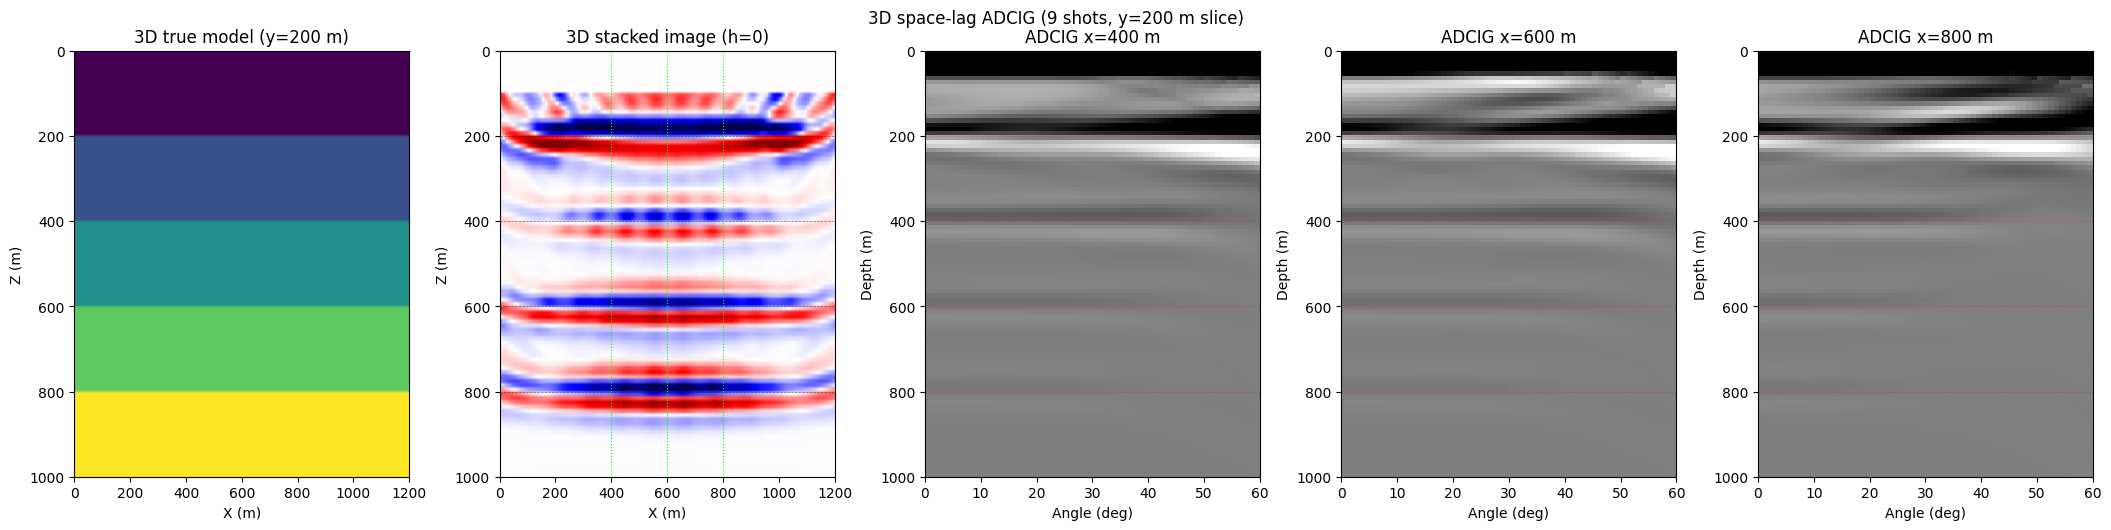

In [4]:
nz3, ny3, nx3 = 100, 40, 120; nt3 = 1300
vp_true3 = np.full((nz3, ny3, nx3), 1500., np.float32)
vp_true3[20:] = 1600.; vp_true3[40:] = 1700.; vp_true3[60:] = 1800.; vp_true3[80:] = 1900.
vp_smooth3 = gaussian_filter1d(vp_true3, sigma=8, axis=0).astype(np.float32)

t3 = np.arange(nt3, dtype=np.float32) * dt
wav3 = (1000.0 * ricker(t3 - 0.1, f=12.0)).astype(np.float32)
yc = ny3 // 2
shot_x3 = np.arange(20, nx3 - 15, 10, dtype=np.int64)
src_list3 = [np.array([[int(sx), yc, 1]], dtype=np.int64) for sx in shot_x3]
gx, gy = np.meshgrid(np.arange(0, nx3, 2), np.arange(0, ny3, 2), indexing='xy')
rec3 = np.stack([gx.ravel(), gy.ravel(), np.ones(gx.size, np.int64)], axis=-1)[None]

L3 = 16; LAGS3 = np.arange(-L3, L3 + 1, dtype=np.int64)
E3, den3 = run_adcig(Acoustic3D(spatial_order=order, device=device), (nz3, ny3, nx3),
                     wav3, src_list3, rec3, vp_true3, vp_smooth3, L3, abcn, dh, dt, nt3)

x_loc3 = [400, 600, 800]; x_cols3 = [int(round(xm / dh)) for xm in x_loc3]
gathers3 = {xm: slant_stack(E3[:, :, yc, xc], LAGS3, angles) for xm, xc in zip(x_loc3, x_cols3)}
img3 = E3[L3][:, yc, :] / (den3[:, yc, :] + 1e-30); img3[:10] = 0

fig, axes = plt.subplots(1, 2 + len(x_cols3), figsize=(4.2 * (2 + len(x_cols3)), 5),
                         constrained_layout=True)
ext = [0, nx3 * dh, nz3 * dh, 0]
axes[0].imshow(vp_true3[:, yc, :], cmap='viridis', aspect='auto', extent=ext)
axes[0].set_title(f'3D true model (y={yc*dh:.0f} m)'); axes[0].set_xlabel('X (m)'); axes[0].set_ylabel('Z (m)')
vl = np.percentile(np.abs(img3), 99) or 1.0
axes[1].imshow(img3, cmap='seismic', vmin=-vl, vmax=vl, aspect='auto', extent=ext)
for zm in REFL_M: axes[1].axhline(zm, color='k', lw=0.5, ls='--', alpha=0.5)
for xm in x_loc3: axes[1].axvline(xm, color='lime', lw=0.8, ls=':')
axes[1].set_title('3D stacked image (h=0)'); axes[1].set_xlabel('X (m)'); axes[1].set_ylabel('Z (m)')
for ax, xm in zip(axes[2:], x_loc3):
    g = gathers3[xm]; vv = np.percentile(np.abs(g[:, 10:]), 98) or 1.0
    ax.imshow(g.T, cmap='gray', vmin=-vv, vmax=vv, aspect='auto', extent=[0, 60, nz3 * dh, 0])
    for zm in REFL_M: ax.axhline(zm, color='r', lw=0.4, ls='--', alpha=0.4)
    ax.set_title(f'ADCIG x={xm} m'); ax.set_xlabel('Angle (deg)'); ax.set_ylabel('Depth (m)')
plt.suptitle(f'3D space-lag ADCIG ({len(shot_x3)} shots, y={yc*dh:.0f} m slice)', y=1.03); plt.show()

## Notes

- **`compute_adcig` is off by default** — zero extra memory/compute when unset
  (`solver.adcig` stays `None`); it only ever runs in the backward, never the
  forward.  When on, cost scales with `adcig_max_lag` (the number of lags).
- **`solver.adcig` holds the space-lag *offset* cube** $E(z,x,h)$, not the angle
  gather — the angle conversion is the `slant_stack` post-process above.  The
  $h{=}0$ slice equals the standard zero-lag RTM image.
- **Boundary-saving only** (the production `impl='c'` path with GPU/int8
  boundary); full/checkpoint raise a clear error.
- Flat gathers ⇒ correct migration velocity; residual moveout ⇒ velocity error —
  the basis of angle-domain MVA.  The mild high-angle curvature here comes from
  migrating on the depth-smoothed (not exact) background.

## References

Sava, P. C., & Fomel, S. (2003). Angle-domain common-image gathers by
wavefield continuation methods. *Geophysics*, 68(3), 1065–1074.
[doi:10.1190/1.1581078](https://doi.org/10.1190/1.1581078)